In [ ]:
'''

print(f"Dataset shape : {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nMonthly_Spending stats:\n{df['Monthly_Spending'].describe().round(2)}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 ─ EDA (Exploratory Data Analysis)
# WHY: Before doing anything, look at your data.
#   - Distributions tell you which transforms are needed
#   - Pair plots reveal correlations between features
#   - Missing pattern tells you imputation strategy
# ─────────────────────────────────────────────────────────────────────────────



# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 ─ TRAIN / TEST SPLIT  ← THIS MUST HAPPEN BEFORE ANY TRANSFORMATION
# WHY THIS ORDER MATTERS:
#   If you impute or scale BEFORE splitting, the test set influences
#   the imputation/scaling parameters → data leakage.
#   The test set must always stay completely invisible during training.
#
#   Correct order:
#   split → fit imputer on X_train → transform X_train and X_test separately
# ─────────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 ─ MISSING VALUE IMPUTATION
#
# Two choices: SimpleImputer vs KNNImputer
#
#   SimpleImputer(strategy='median')
#   → fills every missing value with the column median
#   → fast, simple, works when features are independent
#   → PROBLEM: ignores relationships between features
#     e.g. a high-income customer likely has high call_minutes too
#     median-imputing income ignores this → wrong fill value
#
#   KNNImputer(n_neighbors=5)
#   → finds 5 most similar rows (by other features) and averages their income
#   → preserves inter-feature correlations
#   → USE THIS when features are correlated (which telecom data usually is)
#   → RULE: if |corr| > 0.3 between Income and any other feature → use KNN
#
#   CRITICAL: fit_transform on X_train, transform only on X_test
# ─────────────────────────────────────────────────────────────────────────────


# Check correlations among numeric features to justify KNN
print("Inter-feature correlations (justify KNN vs SimpleImputer):")
num_train = X_train.select_dtypes(include=np.number)
corr_matrix = num_train.corr()
income_corrs = corr_matrix['Income'].drop('Income').abs().sort_values(ascending=False)
print(income_corrs.round(3))
print(f"\nHighest |corr| with Income = {income_corrs.max():.3f}")
print("→ Features are correlated → KNNImputer is the right choice")
print("  (If max corr < 0.2 → SimpleImputer(median) would be fine)")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 ─ OUTLIER DETECTION & TREATMENT
#
# THREE methods — when to use each:
#
#   IQR (Interquartile Range)
#   → flags values below Q1-1.5×IQR or above Q3+1.5×IQR
#   → non-parametric: works on skewed distributions
#   → USE WHEN: distribution is skewed (like income)
#   → ACTION: winsorize (cap) rather than drop rows
#
#   Z-score (|z| > 3)
#   → flags values more than 3 standard deviations from mean
#   → assumes normality — WRONG for skewed data
#   → USE WHEN: distribution is already normal
#
#   IsolationForest
#   → finds rows that are unusual across MULTIPLE features at once
#   → USE WHEN: outliers exist in combinations (e.g. very old + very high income)
#
# WHY WINSORIZE INSTEAD OF DROP?
#   Dropping rows loses data and can introduce bias.
#   Winsorizing caps extreme values at the 1st/99th percentile.
#   The row stays in the dataset, but the extreme value is softened.
#
# WHEN TO LOG vs SQRT vs WINSORIZE?
#   Winsorize: outliers exist but distribution is otherwise okay → cap them
#   Log:       distribution is right-skewed across whole range → compress scale
#   Sqrt:      mild right skew, or known sqrt relationship (like tenure here)
# ─────────────────────────────────────────────────────────────────────────────


# ── Detect: IQR check on Income
Q1 = X_train['Income'].quantile(0.25)
Q3 = X_train['Income'].quantile(0.75)
IQR_val = Q3 - Q1
iqr_outliers = ((X_train['Income'] < Q1 - 1.5*IQR_val) |
                (X_train['Income'] > Q3 + 1.5*IQR_val)).sum()

print(f"Income outliers (IQR method): {iqr_outliers}")
print(f"  Lower fence: {Q1 - 1.5*IQR_val:,.0f}")
print(f"  Upper fence: {Q3 + 1.5*IQR_val:,.0f}")

print("\nIncome is right-skewed with extreme values → Winsorize at 1%/99%")



# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 ─ MULTICOLLINEARITY CHECK
#
# TWO-stage approach:
#
#   Stage A — Correlation matrix
#   → Quick visual scan
#   → |corr| > 0.7 between two features = suspect multicollinearity
#   → Does NOT tell you the full picture (only pairwise)
#
#   Stage B — VIF (Variance Inflation Factor)
#   → Measures how much each feature's variance is inflated
#     by ALL other features together (not just pairwise)
#   → VIF = 1       : perfectly independent
#   → VIF 1–5       : acceptable
#   → VIF 5–10      : investigate
#   → VIF > 10      : serious — take action
#
# WHAT TO DO BASED ON GOAL:
#   Goal = Interpretation  → Drop one of the correlated variables
#                            (keep size_sqft, drop size_m2 — same info, clearer unit)
#   Goal = Prediction      → Use Ridge Regression (penalises large coefficients)
#   Many correlated vars   → PCA + Regression (loses interpretability)
#
# WHY MULTICOLLINEARITY IS A PROBLEM:
#   The model can't decide which of two correlated features to "credit" for
#   predicting the target. Coefficients become unstable — a tiny change in
#   data causes a huge sign flip. The predictions may still be okay, but
#   the coefficients are meaningless.
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 ─ JUSTIFIED FEATURE DROP DECISION
#
# Now we drop features — but with EVIDENCE, not intuition.
#
# Income_Copy: VIF > 10,000, corr with Income = 0.99+
#   → Identical information. Drop it.
#   → In real data this is like having size_sqft AND size_m2 both as features.
#
# Age: correlation with Monthly_Spending ≈ 0.01
#   → Adds almost no signal. VIF is fine, but it doesn't help predictions.
#   → Drop for simplicity.
#
# Satisfaction: correlation with Monthly_Spending ≈ 0.00
#   → Random integers 1–10. No relationship to spending. Drop.
#
# NOTE: If a feature has low correlation BUT high VIF → still drop
#       (it's hurting coefficient stability even if it doesn't predict well)
# ─────────────────────────────────────────────────────────────────────────────

# Compute correlation with target on training data
corr_target = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
target_corr = corr_target.corr()['Monthly_Spending'].drop('Monthly_Spending')
print("Correlation with Monthly_Spending:")
print(target_corr.sort_values(key=abs, ascending=False).round(4))

DROP_COLS = ['Income_Copy', 'Age', 'Satisfaction']


X_train.drop(DROP_COLS, axis=1, inplace=True)
X_test.drop(DROP_COLS, axis=1, inplace=True)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 ─ TARGET VARIABLE ANALYSIS
#
# When to log-transform the target:
#   ✓ Target is right-skewed (skew > 1)         → log compresses long tail
#   ✓ Residuals fan out (heteroscedasticity)    → log stabilises variance
#   ✓ Target spans multiple orders of magnitude → log makes scale uniform
#
# When NOT to log-transform:
#   ✗ Target is already symmetric (skew near 0)
#   ✗ Target has zero or negative values (use log1p or shift first)
#
# For Monthly_Spending: skew is near 0 (normally distributed target)
# → No log transform needed for the target here.
# → The NON-LINEARITY is in TENURE (sqrt), handled in the pipeline transform.
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 ─ COLUMN TRANSFORMER PIPELINE + FIT
#
# ColumnTransformer applies DIFFERENT transforms to DIFFERENT columns.
# This is the right way — never apply the same transform blindly to all features.
#
# Feature-by-feature decisions:
#
#   Income       → log1p + StandardScaler
#                  WHY log: still right-skewed even after winsorizing
#                  WHY scale: gradient descent converges faster on scaled data
#
#   Tenure       → sqrt + StandardScaler
#                  WHY sqrt: the data-generating formula uses sqrt(tenure)
#                  In real data: tenure often has diminishing returns
#                  (year 1→2 is a big change, year 50→51 is tiny)
#
#   Data_Usage   → StandardScaler only
#                  WHY: approximately normal distribution already
#
#   Call_Minutes → StandardScaler only
#                  WHY: approximately normal distribution already
#
# WHY StandardScaler?
#   Linear Regression is not sensitive to scale (no regularisation),
#   but Ridge IS sensitive. We scale so that:
#   (a) Coefficients are comparable across features
#   (b) Ridge penalises all features equally
#   (c) The model works correctly if we switch to Ridge later
#
# RULE: log → scale (always scale AFTER log, not before)
# RULE: fit_transform on X_train only, transform on X_test
# ─────────────────────────────────────────────────────────────────────────────



# ─────────────────────────────────────────────────────────────────────────────
# STEP 9 ─ ASSUMPTION 1: LINEARITY
#
# Check: Residuals vs Fitted plot
# What to look for:
#   ✓ Random horizontal cloud around zero → linearity holds
#   ✗ U-shape or curve pattern → non-linearity (add polynomial feature or log)
#   ✗ Systematic direction → missing important feature
#
# We already handled Tenure's non-linearity via sqrt transform.
# This plot verifies it worked.
# ─────────────────────────────────────────────────────────────────────────────


# Check: are residuals randomly distributed?
corr_resid_fitted = abs(np.corrcoef(y_pred_lr, resid_lr)[0, 1])
print(f"Correlation between residuals and fitted values: {corr_resid_fitted:.4f}")
print(f"→ {'Linearity holds ✓' if corr_resid_fitted < 0.1 else 'Non-linearity detected ✗ — add polynomial features'}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 10 ─ ASSUMPTION 2: NORMALITY OF RESIDUALS
#
# Why it matters:
#   p-values, t-tests on coefficients, and confidence intervals
#   all assume residuals are normally distributed.
#   For PREDICTIONS (R², RMSE) → normality doesn't matter much.
#   For INFERENCE (is this coefficient significant?) → it matters.
#   With n > 200, Central Limit Theorem largely saves you anyway.
#
# How to check:
#   Histogram: should look like a bell curve
#   Q-Q plot:  dots should follow the diagonal line
#   Shapiro-Wilk test: p > 0.05 = normal (use on sample ≤ 200 for power)
#
# What to do if violated:
#   Option 1: log-transform the target (if skewed)
#   Option 2: remove extreme outliers pulling the tail
#   Option 3: use HuberRegressor (robust to non-normal errors)
#   Option 4: with n > 500, largely ignore — CLT covers you for predictions
# ─────────────────────────────────────────────────────────────────────────────



# ─────────────────────────────────────────────────────────────────────────────
# STEP 11 ─ ASSUMPTION 3: HOMOSCEDASTICITY
#
# What it means:
#   The spread of residuals should be CONSTANT across all fitted values.
#   Homo = same, scedastic = scatter/spread.
#
# What heteroscedasticity looks like:
#   Residual vs Fitted plot shows a CONE/FAN shape:
#   small spread for low predictions, large spread for high predictions.
#
# Why it matters:
#   Standard errors are wrong → t-tests and confidence intervals are unreliable.
#   The model pretends to be equally confident everywhere when it isn't.
#
# How to detect:
#   Plot 1: Residuals vs Fitted → look for fan/cone shape
#   Plot 2: Scale-Location plot → sqrt(|residuals|) vs fitted → should be flat
#   Test: Breusch-Pagan test → p < 0.05 = heteroscedasticity detected
#
# What to do if violated:
#   Option 1: log(y) — most effective fix for price/spending data
#   Option 2: Weighted Least Squares (WLS) — give noisy predictions less weight
#   Option 3: statsmodels with cov_type='HC3' → robust standard errors
#             (doesn't fix the problem but gives correct standard errors anyway)
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# STEP 12 ─ FINAL METRICS + MODEL COMPARISON
#
# Metrics explained:
#   R²   → proportion of variance explained (0 to 1, higher = better)
#          0.8 means the model explains 80% of variance in spending
#   RMSE → average error in the same unit as target ($)
#          penalises large errors more than small ones
#   MAE  → average absolute error in $ (more interpretable)
#          50% of predictions are within ±MAE of the true value
#
# LR vs Ridge:
#   If R² and RMSE are very similar → multicollinearity was already fixed
#   If Ridge is significantly better → residual multicollinearity exists
# ─────────────────────────────────────────────────────────────────────────────


'''

Dataset shape: (5000, 8)
Missing values:
Age                   0
Income              250
Income_Copy           0
Tenure                0
Data_Usage            0
Call_Minutes          0
Satisfaction          0
Monthly_Spending      0
dtype: int64
STEP 1: EDA - Understanding the data


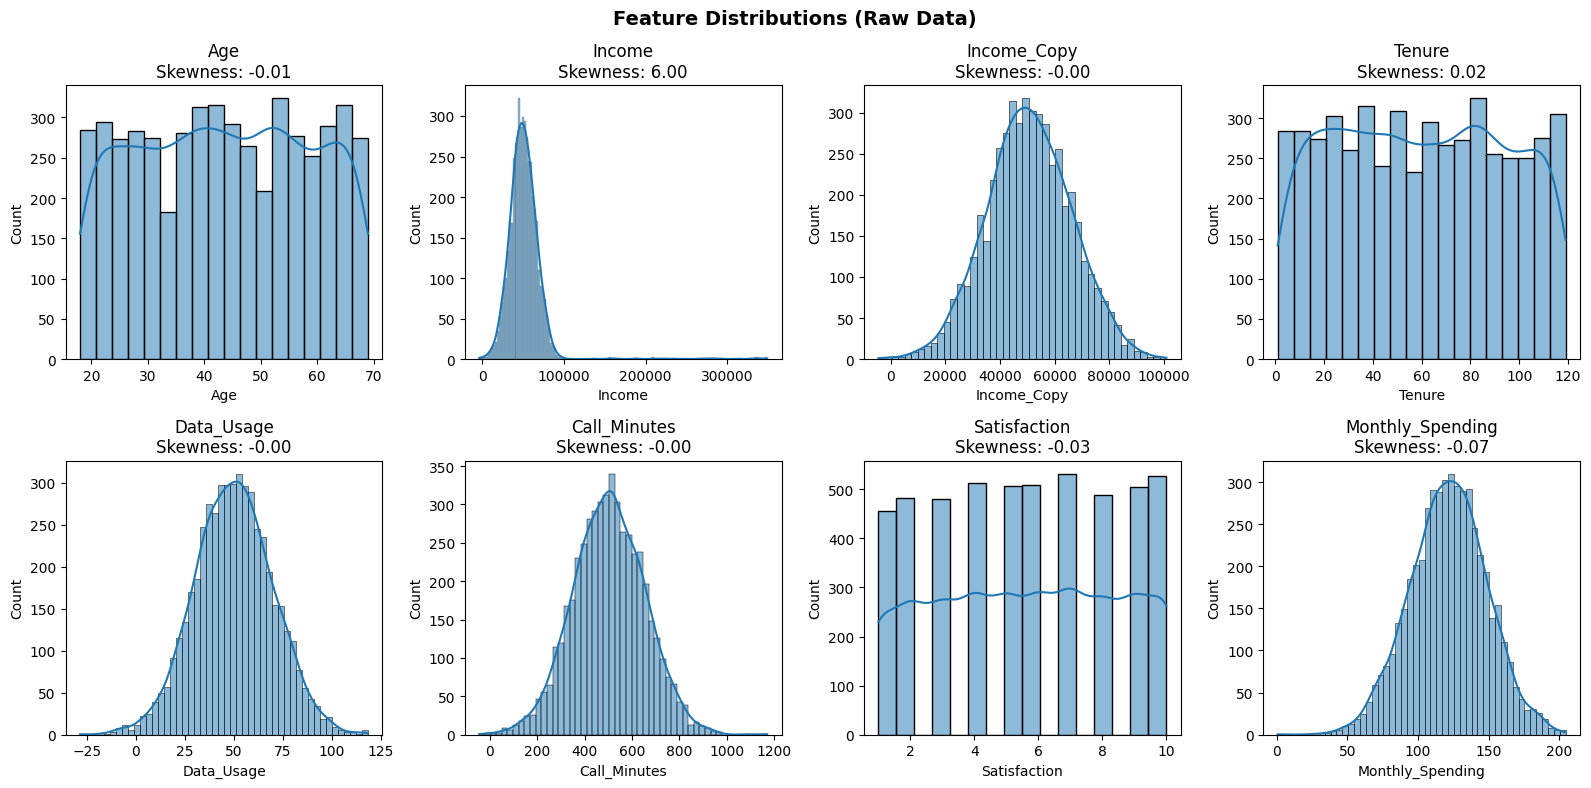


Correlation with Monthly Spending:
Monthly_Spending    1.0000
Tenure              0.4570
Income_Copy         0.4496
Income              0.3065
Call_Minutes        0.1560
Data_Usage          0.1323
Satisfaction        0.0072
Age                -0.0097
Name: Monthly_Spending, dtype: float64


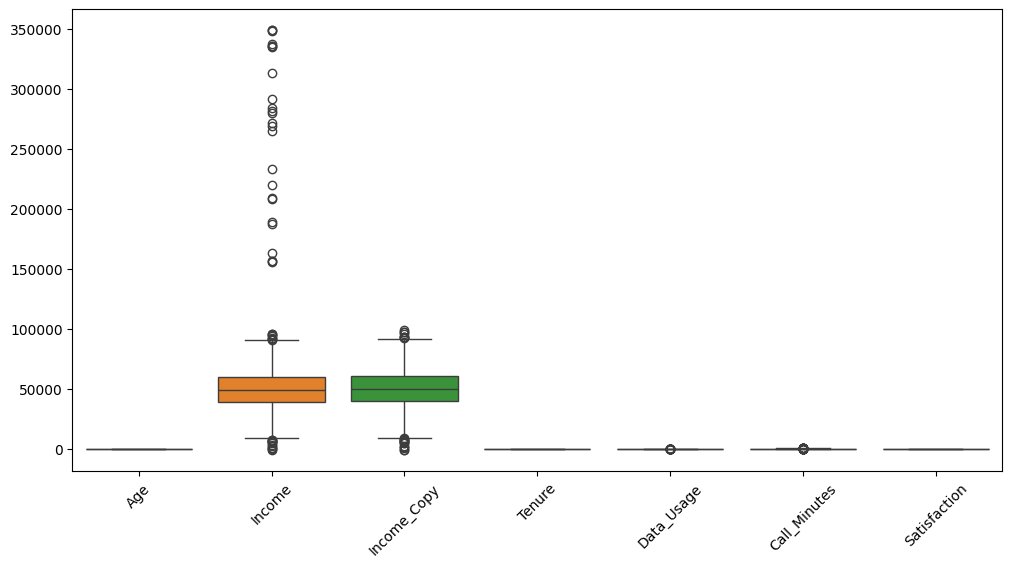

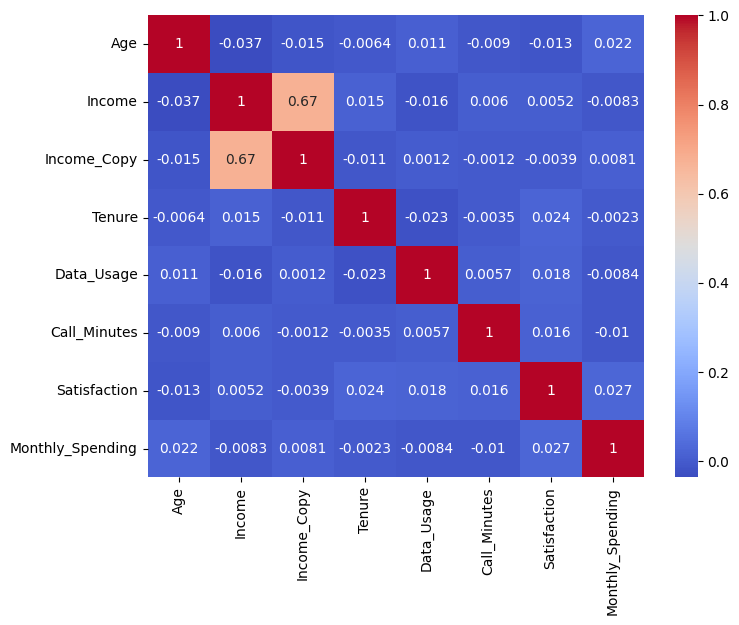

R2 : 0.41958922961263256
MAE : 16.213240249219506
RMSE : 20.362517018616348


In [ ]:
# ============================================
# TELECOM CUSTOMER SPENDING PREDICTION
# Predicting monthly spending from customer data
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================
# STEP 0: CREATE DATASET (with intentional problems)
# ============================================


np.random.seed(42)
n = 5000

# Generate features
age = np.random.randint(18, 70, n)
income = np.random.normal(50000, 15000, n)
tenure = np.random.randint(1, 120, n)
data_usage = np.random.normal(50, 20, n)
call_minutes = np.random.normal(500, 150, n)
satisfaction = np.random.randint(1, 11, n)

# Intentional problem 1: Income_Copy (multicollinearity)
income_copy = income * 1.02 + np.random.normal(0, 1000, n)

# Create target variable (Monthly Spending)
monthly_spending = (
    20
    + 0.0008 * income
    + 0.2 * data_usage
    + 0.03 * call_minutes
    + 5 * np.sqrt(tenure)  # Non-linear relationship!
    + np.random.normal(0, 20, n)
)

df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Income_Copy': income_copy,
    'Tenure': tenure,
    'Data_Usage': data_usage,
    'Call_Minutes': call_minutes,
    'Satisfaction': satisfaction,
    'Monthly_Spending': monthly_spending
})

# Intentional problem 2: Missing values in Income (5%)
df.loc[df.sample(frac=0.05, random_state=42).index, 'Income'] = np.nan

# Intentional problem 3: Outliers in Income (30 rows x 5)
outlier_idx = np.random.choice(df.index, 30, replace=False)
df.loc[outlier_idx, 'Income'] *= 5

print(f"Dataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")


# ============================================
# STEP 1: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

print("STEP 1: EDA - Understanding the data")


# Distribution plots (Graphs)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(['Age', 'Income', 'Income_Copy', 'Tenure',
                           'Data_Usage', 'Call_Minutes', 'Satisfaction', 'Monthly_Spending']):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx])
    axes[idx].set_title(f'{col}\nSkewness: {df[col].dropna().skew():.2f}')

plt.suptitle('Feature Distributions (Raw Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
print("\nCorrelation with Monthly Spending:")
correlations = df.corr(numeric_only=True)['Monthly_Spending'].sort_values(ascending=False)
print(correlations.round(4))



#### STEP 2 using the train and split

X = df.drop('Monthly_Spending', axis=1)
y = df['Monthly_Spending']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# STEP 3 ─ MISSING VALUE IMPUTATION
#
# Two choices: SimpleImputer vs KNNImputer
#
#   SimpleImputer(strategy='median')
#   → fills every missing value with the column median
#   → fast, simple, works when features are independent
#   → PROBLEM: ignores relationships between features
#     e.g. a high-income customer likely has high call_minutes too
#     median-imputing income ignores this → wrong fill value
#
#   KNNImputer(n_neighbors=5)
#   → finds 5 most similar rows (by other features) and averages their income
#   → preserves inter-feature correlations
#   → USE THIS when features are correlated (which telecom data usually is)
#   → RULE: if |corr| > 0.3 between Income and any other feature → use KNN


imputer = KNNImputer(n_neighbors=5)
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)


 ### FOR outlier dectection
### import
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

sns.boxplot(data=X_train)

plt.xticks(rotation=45)
plt.show()


##### for corr
#STEP 5 ─ MULTICOLLINEARITY CHECK
#
# TWO-stage approach:
#
#   Stage A — Correlation matrix
#   → Quick visual scan
#   → |corr| > 0.7 between two features = suspect multicollinearity
#   → Does NOT tell you the full picture (only pairwise)
#

corr_df = pd.concat(
    [X_train, y_train],
    axis=1
)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()


from scipy.stats.mstats import winsorize


X_train["Income"] = winsorize(
    X_train["Income"],
    limits=[0.01,0.01]
)

X_test["Income"] = winsorize(
    X_test["Income"],
    limits=[0.01,0.01]
)

X_train["Income"].max()


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler
)

preprocessor = ColumnTransformer(

    transformers=[

        (
            'income',

            Pipeline([
                ('log', FunctionTransformer(np.log1p)),
                ('scaler', StandardScaler())
            ]),

            ['Income']
        ),

        (
            'tenure',

            Pipeline([
                ('sqrt', FunctionTransformer(np.sqrt)),
                ('scaler', StandardScaler())
            ]),

            ['Tenure']
        ),

        (
            'other',

            Pipeline([
                ('scaler', StandardScaler())
            ]),

            ['Data_Usage','Call_Minutes']
        )

    ]
)



model = Pipeline([

    ('preprocessor', preprocessor),

    ('regressor', LinearRegression())

])

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        Ridge(alpha=10.0))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test,y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("R2 :",r2)
print("MAE :",mae)
print("RMSE :",rmse)

